In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Crop_Project/augmented_crop_dataset.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.shape

(11000, 8)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            11000 non-null  int64  
 1   P            11000 non-null  int64  
 2   K            11000 non-null  int64  
 3   temperature  11000 non-null  float64
 4   humidity     11000 non-null  float64
 5   ph           11000 non-null  float64
 6   rainfall     11000 non-null  float64
 7   label        11000 non-null  object 
dtypes: float64(4), int64(3), object(1)
memory usage: 687.6+ KB


In [7]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,50.350000,53.075364,47.789182,25.650903,71.464164,6.465606,103.455597
std,36.713969,32.878019,50.598311,4.915100,22.166631,0.704691,54.819979
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,27.000000,20.000000,22.765054,60.179546,5.988871,64.790911
50%,36.000000,51.000000,31.000000,25.635120,80.607703,6.441411,94.604307
75%,85.000000,68.000000,49.000000,28.527609,90.026054,6.880258,123.791223
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [10]:
df['label'].value_counts()

,count
label,
rice,500
maize,500
chickpea,500
kidneybeans,500
pigeonpeas,500
mothbeans,500
mungbean,500
blackgram,500
lentil,500


In [11]:
num_df = df.select_dtypes(include=['number'])
cv = (num_df.std() / num_df.mean()) * 100
print(cv)

N               72.917515
P               61.945914
K              105.878171
temperature     19.161509
humidity        31.017828
ph              10.899066
rainfall        52.988896
dtype: float64


In [12]:
num_df = df.select_dtypes(include=['number'])

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = num_df[(num_df[col] < lower) | (num_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

N: 0 outliers
P: 654 outliers
K: 1000 outliers
temperature: 430 outliers
humidity: 95 outliers
ph: 252 outliers
rainfall: 508 outliers


In [13]:
num_df = df.select_dtypes(include=['number'])
correlation = num_df.corr()
print(correlation)

                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.233245 -0.143237     0.024683  0.193275  0.108448   
P           -0.233245  1.000000  0.738602    -0.130006 -0.119175 -0.154496   
K           -0.143237  0.738602  1.000000    -0.159239  0.192361 -0.185440   
temperature  0.024683 -0.130006 -0.159239     1.000000  0.219390 -0.013254   
humidity     0.193275 -0.119175  0.192361     0.219390  1.000000 -0.011122   
ph           0.108448 -0.154496 -0.185440    -0.013254 -0.011122  1.000000   
rainfall     0.068433 -0.064527 -0.053749    -0.029916  0.098101 -0.120451   

             rainfall  
N            0.068433  
P           -0.064527  
K           -0.053749  
temperature -0.029916  
humidity     0.098101  
ph          -0.120451  
rainfall     1.000000  


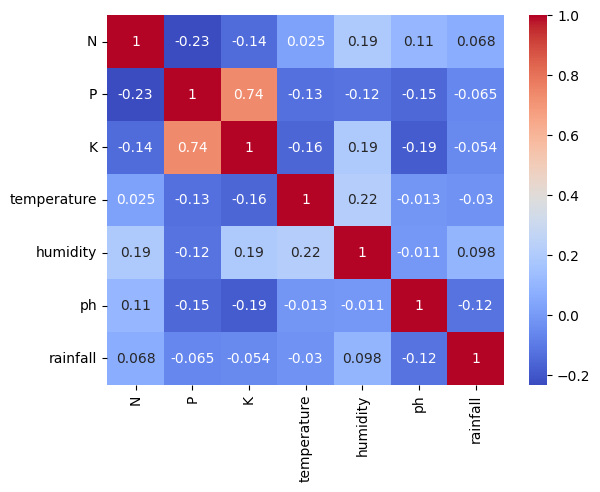

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [15]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

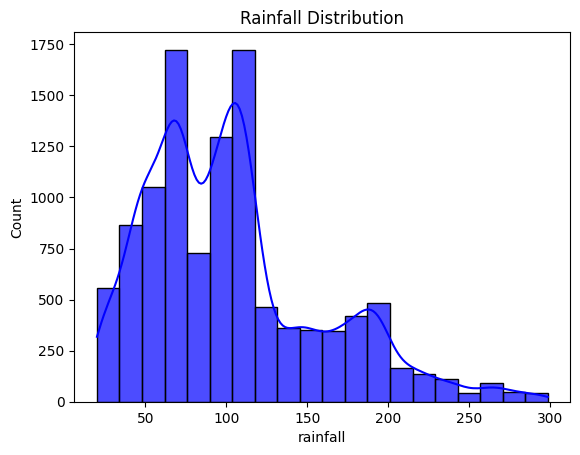

In [17]:
sns.histplot(
    df['rainfall'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

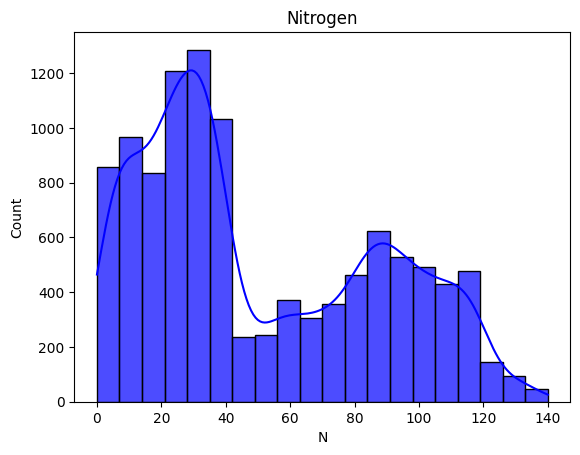

In [18]:
sns.histplot(
    df['N'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Nitrogen")
plt.show()

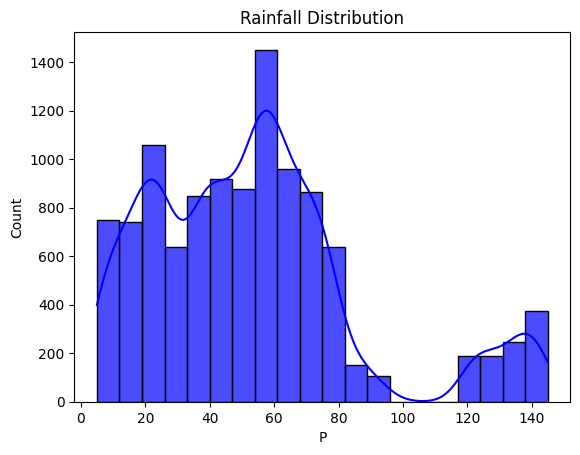

In [19]:
sns.histplot(
    df['P'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

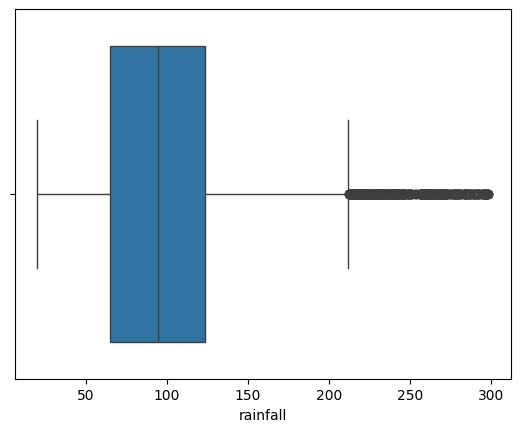

In [20]:
sns.boxplot(x=df['rainfall'])
plt.show()

In [21]:
df['rainfall'].skew()

np.float64(0.969233818991298)

In [22]:
Q1 = df['rainfall'].quantile(0.25)
Q3 = df['rainfall'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['rainfall'] < lower) | (df['rainfall'] > upper)]
print(lower)
print(upper)
print(outliers['rainfall'])

-23.70955836990889
212.29169256311047
1        226.655537
2        263.964248
3        242.864034
4        262.717340
5        251.055000
            ...    
10593    293.837138
10594    278.740251
10595    270.164173
10597    279.348352
10599    240.357783
Name: rainfall, Length: 508, dtype: float64


In [23]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [24]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'chickpea': 3,
    'kidneybeans': 4,
    'pigeonpeas': 5,
    'mothbeans': 6,
    'mungbean': 7,
    'blackgram': 8,
    'lentil': 9,
    'pomegranate': 10,
    'banana': 11,
    'mango': 12,
    'grapes': 13,
    'watermelon': 14,
    'muskmelon': 15,
    'apple': 16,
    'orange': 17,
    'papaya': 18,
    'coconut': 19,
    'cotton': 20,
    'jute': 21,
    'coffee': 22
}

In [25]:
df['label'] = df['label'].map(crop_dict)

In [26]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [27]:
X=df.drop('label',axis=1)
y=df['label']

In [28]:
print(y)


0         1
1         1
2         1
3         1
4         1
         ..
10995    14
10996    14
10997    14
10998    14
10999    14
Name: label, Length: 11000, dtype: int64


In [29]:
print(y)

0         1
1         1
2         1
3         1
4         1
         ..
10995    14
10996    14
10997    14
10998    14
10999    14
Name: label, Length: 11000, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
X_train.shape

(8800, 7)

In [32]:
X_test.shape

(2200, 7)

In [33]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [34]:
X_train

array([[ 0.8616113 , -0.88361186,  0.06151773, ...,  0.71207408,
        -0.52760549, -1.0155491 ],
       [-1.15080317,  0.11774572, -0.58931648, ..., -2.13152314,
        -1.10547508, -0.53644513],
       [-1.25958233,  0.08740155, -0.53014973, ..., -0.5270475 ,
         0.50063427, -1.2315873 ],
       ...,
       [-0.525323  ,  2.54527924,  2.94096603, ...,  0.5232761 ,
        -0.8076813 , -0.61691512],
       [-0.49812821,  0.75497327, -0.51042748, ..., -0.4132585 ,
         0.76955546, -0.91503225],
       [-0.30776468, -1.12636521, -0.2737605 , ..., -0.99838574,
        -0.44803121, -0.24359072]])

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [142]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(max_depth=9)
}

In [143]:
results = {}
predictions = {}
train_scores = {}
test_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = accuracy_score(y_train, train_pred)
    results[name] = test_acc
    predictions[name] = y_pred
    train_scores[name] = train_acc
    test_scores[name] = test_acc

In [144]:
for name in models:
    print(f"\n{name}")
    print("Train Accuracy:", train_scores[name])
    print("Test Accuracy :", test_scores[name])


LogisticRegression
Train Accuracy: 0.9875
Test Accuracy : 0.9845454545454545

SVC
Train Accuracy: 0.9926136363636363
Test Accuracy : 0.9918181818181818

KNeighborsClassifier
Train Accuracy: 0.9970454545454546
Test Accuracy : 0.9954545454545455

DecisionTreeClassifier
Train Accuracy: 0.9846590909090909
Test Accuracy : 0.9845454545454545


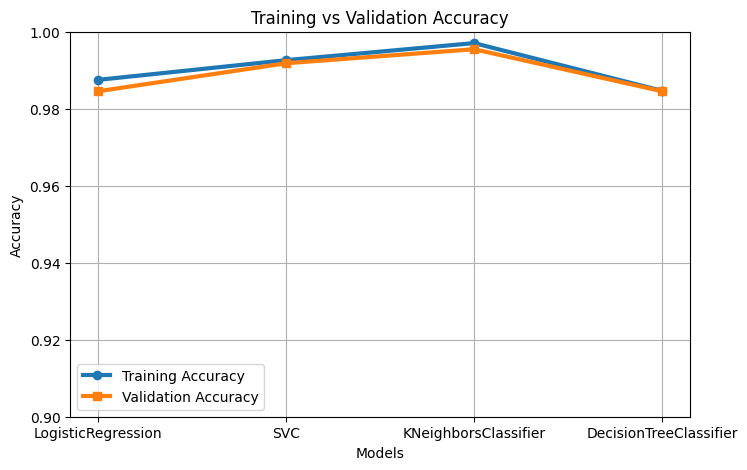

In [145]:
import matplotlib.pyplot as plt

# Convert dictionary keys and values into lists
model_names = list(train_scores.keys())

train_values = list(train_scores.values())
test_values = list(test_scores.values())

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(
    model_names,
    train_values,
    marker='o',
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    model_names,
    test_values,
    marker='s',
    linewidth=3,
    label="Validation Accuracy"
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.ylim(0.90, 1.00)

plt.legend()
plt.grid(True)

plt.show()

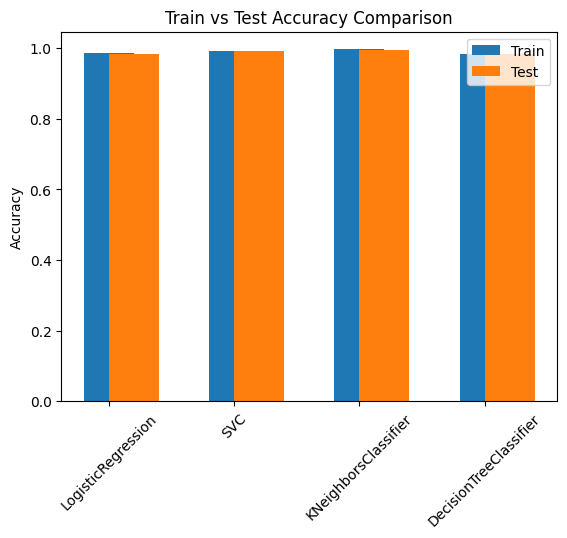

In [146]:
import matplotlib.pyplot as plt
names = list(models.keys())
train_vals = list(train_scores.values())
test_vals = list(test_scores.values())
x = range(len(names))
plt.bar(x, train_vals, width=0.4, label='Train', align='center')
plt.bar(x, test_vals, width=0.4, label='Test', align='edge')
plt.xticks(x, names, rotation=45)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.legend()
plt.show()

In [147]:
for name, score in results.items():
    print(name, ":", score)

LogisticRegression : 0.9845454545454545
SVC : 0.9918181818181818
KNeighborsClassifier : 0.9954545454545455
DecisionTreeClassifier : 0.9845454545454545


In [148]:
import pandas as pd
from sklearn.metrics import accuracy_score
reverse_dict = {v:k for k,v in crop_dict.items()}
for name, model in models.items():
    print(f"\n{name} Evaluation:\n")
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    correct = (preds == y_test).sum()
    wrong = (preds != y_test).sum()
    actual_labels = [reverse_dict[y] for y in y_test]
    predicted_labels = [reverse_dict[p] for p in preds]
    comparison = pd.DataFrame({
        "Actual": actual_labels,
        "Predicted": predicted_labels
    })
    print(f"Accuracy          : {acc * 100:.2f}%")
    print(f"Correct Predictions: {correct}")
    print(f"Wrong Predictions  : {wrong}")
    print("\nSample Predictions:\n")
    print(comparison.head(10))
    print("\n" + "="*60)


LogisticRegression Evaluation:

Accuracy          : 98.45%
Correct Predictions: 2166
Wrong Predictions  : 34

Sample Predictions:

      Actual  Predicted
0      maize      maize
1       jute       jute
2      maize      maize
3    coconut    coconut
4  blackgram  blackgram
5    coconut    coconut
6  blackgram  blackgram
7      maize      maize
8     coffee     coffee
9     orange     orange


SVC Evaluation:

Accuracy          : 99.18%
Correct Predictions: 2182
Wrong Predictions  : 18

Sample Predictions:

      Actual  Predicted
0      maize      maize
1       jute       jute
2      maize      maize
3    coconut    coconut
4  blackgram  blackgram
5    coconut    coconut
6  blackgram  blackgram
7      maize      maize
8     coffee     coffee
9     orange     orange


KNeighborsClassifier Evaluation:

Accuracy          : 99.55%
Correct Predictions: 2190
Wrong Predictions  : 10

Sample Predictions:

      Actual  Predicted
0      maize      maize
1       jute       jute
2      maize   

In [149]:
data = [
    # 1. Rice (Needs massive rainfall, high nitrogen, high humidity)
    [90, 42, 43, 26.5, 82.0, 6.4, 250.0],

    # 2. Coffee (Needs high nitrogen, lower humidity, moderate rainfall)
    [105, 15, 30, 25.6, 58.3, 6.8, 150.0],

    # 3. Apple (Needs huge amounts of Phosphorus and Potassium, cooler temps)
    [20, 125, 200, 22.1, 92.3, 5.9, 110.0],

    # 4. Muskmelon (Needs high temperatures, low rainfall)
    [100, 17, 50, 28.8, 92.1, 6.3, 25.0],

    # 5. Cotton (Needs high nitrogen, moderate rainfall)
    [120, 40, 20, 24.0, 80.0, 6.9, 85.0],

    # 6. Lentil (Needs high phosphorus, lower humidity, low rainfall)
    [15, 65, 20, 29.9, 60.0, 7.5, 45.0],

    # 7. Banana (Needs high nitrogen & phosphorus, high humidity)
    [100, 75, 50, 27.3, 80.4, 6.0, 100.0],

    # 8. Mango (Needs high temperatures, lower humidity)
    [20, 25, 25, 30.0, 50.1, 5.5, 95.0]
]

In [150]:
data_scaled = sc.transform(data)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [151]:
reverse_dict = {v: k for k, v in crop_dict.items()}

for name, model in models.items():
    preds = model.predict(data_scaled)
    print(f"\n{name} predictions:")

    for i, p in enumerate(preds):
        print(f"Row {i+1} → {reverse_dict[p]}")


LogisticRegression predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → mothbeans
Row 7 → banana
Row 8 → mango

SVC predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → lentil
Row 7 → banana
Row 8 → mango

KNeighborsClassifier predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → lentil
Row 7 → banana
Row 8 → mango

DecisionTreeClassifier predictions:
Row 1 → rice
Row 2 → coffee
Row 3 → apple
Row 4 → muskmelon
Row 5 → cotton
Row 6 → blackgram
Row 7 → banana
Row 8 → mango


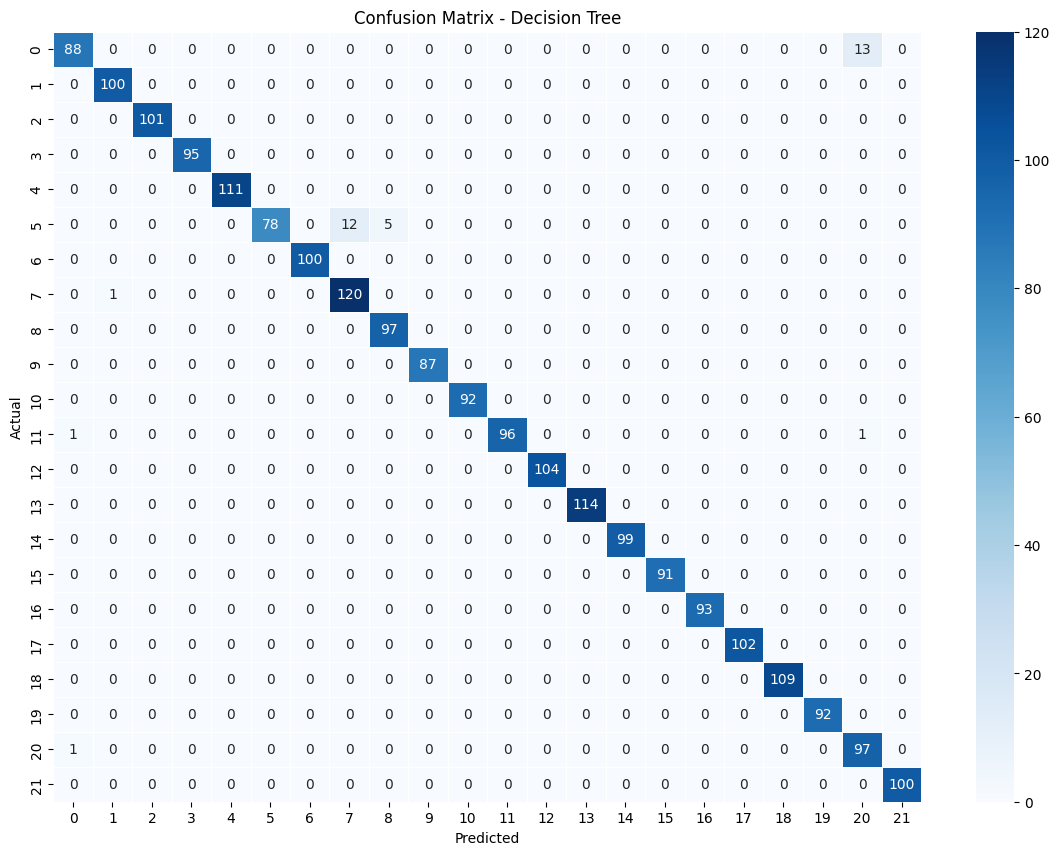

In [152]:
cm = confusion_matrix(y_test, predictions['DecisionTreeClassifier'])
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

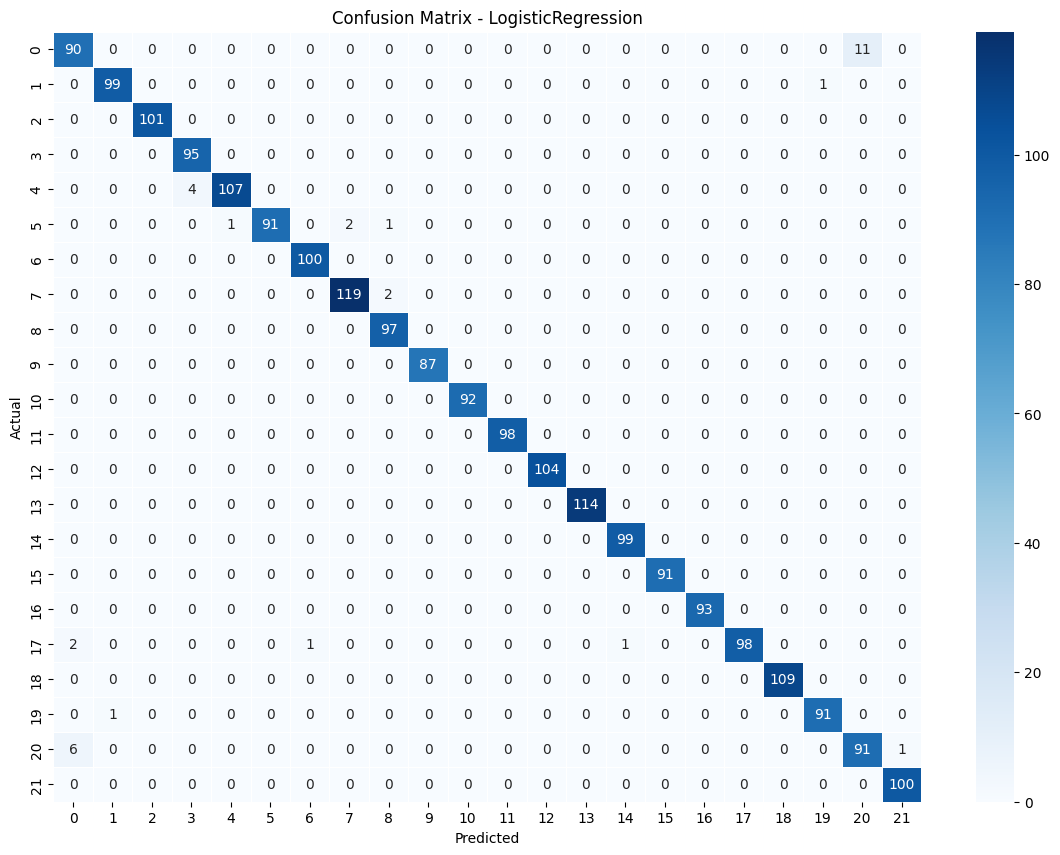

In [153]:
cm = confusion_matrix(y_test, predictions['LogisticRegression'])
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title("Confusion Matrix - LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

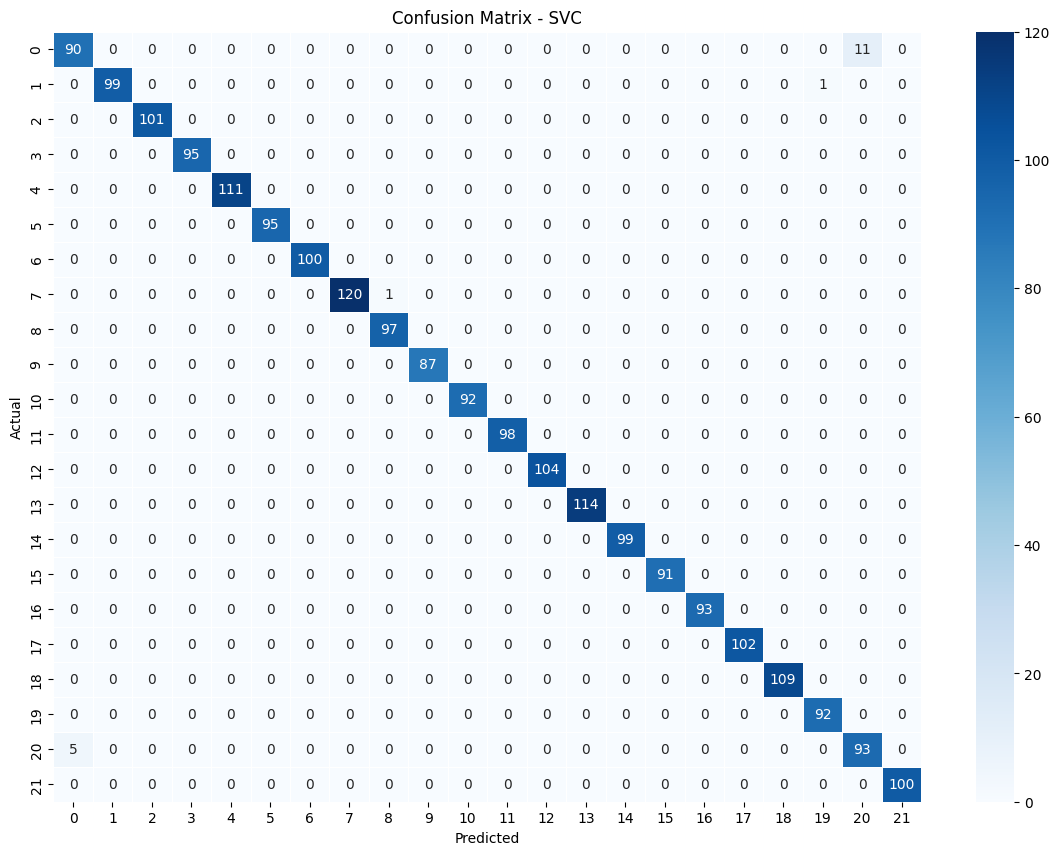

In [154]:
cm = confusion_matrix(y_test, predictions['SVC'])
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

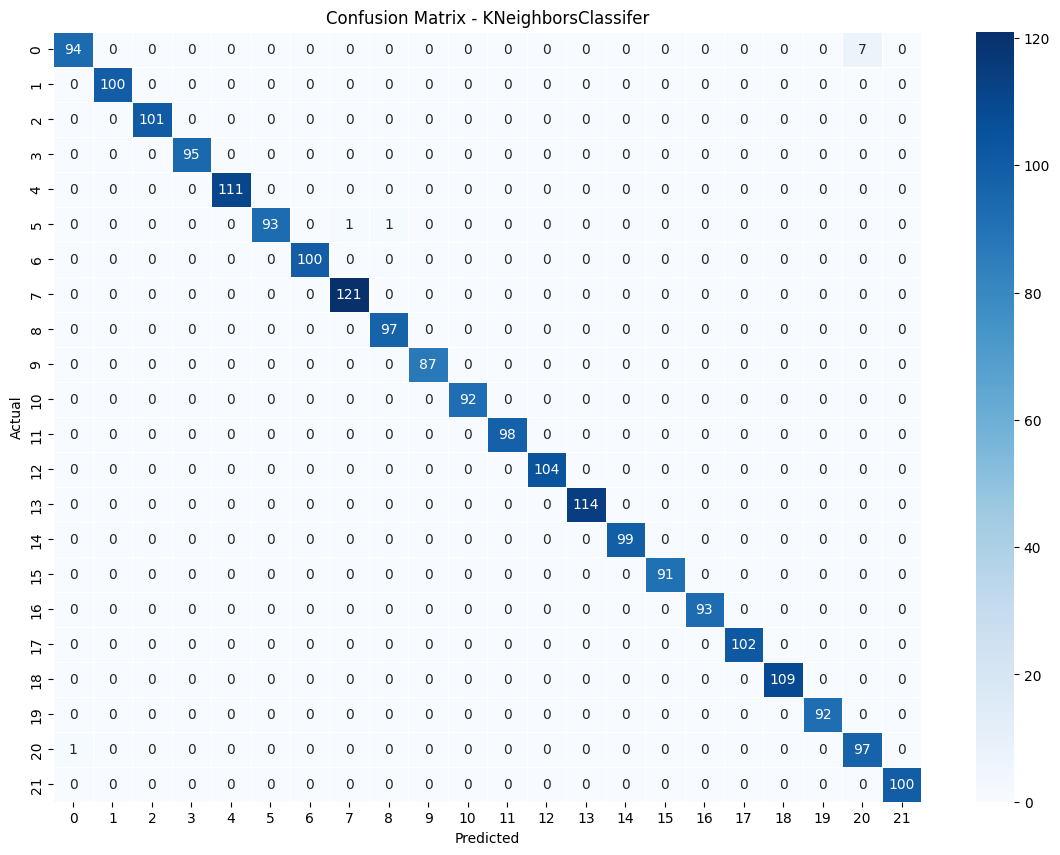

In [155]:
cm = confusion_matrix(y_test, predictions['KNeighborsClassifier'])
plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title("Confusion Matrix - KNeighborsClassifer")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [156]:
from sklearn.metrics import classification_report

for name in predictions:
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, predictions[name]))


LogisticRegression Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.89      0.90       101
           2       0.99      0.99      0.99       100
           3       1.00      1.00      1.00       101
           4       0.96      1.00      0.98        95
           5       0.99      0.96      0.98       111
           6       1.00      0.96      0.98        95
           7       0.99      1.00      1.00       100
           8       0.98      0.98      0.98       121
           9       0.97      1.00      0.98        97
          10       1.00      1.00      1.00        87
          11       1.00      1.00      1.00        92
          12       1.00      1.00      1.00        98
          13       1.00      1.00      1.00       104
          14       1.00      1.00      1.00       114
          15       0.99      1.00      0.99        99
          16       1.00      1.00      1.00        91
          17       1.00      1.00    

In [157]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier


In [158]:
estimators = [
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(max_depth=8)),
    ('lr', LogisticRegression(max_iter=1000))
]

In [159]:
meta_model = RandomForestClassifier(n_estimators=100)

In [160]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

In [161]:
stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('svc', SVC(probability=True)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(max_depth=8)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=RandomForestClassifier())

In [162]:
y_pred_stack = stack_model.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.9968181818181818


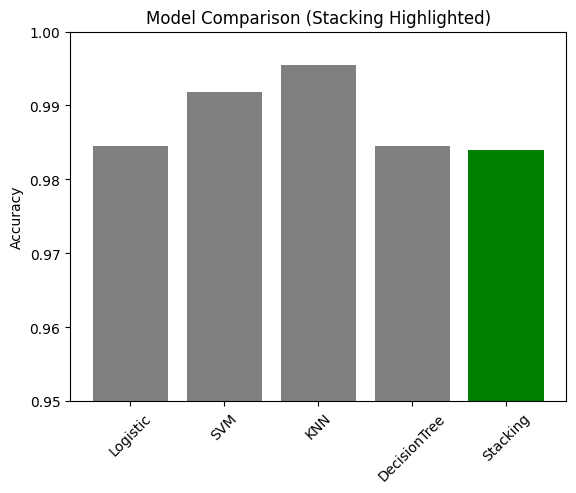

In [163]:
names = ['Logistic', 'SVM', 'KNN', 'DecisionTree', 'Stacking']
values = [
    results['LogisticRegression'],
    results['SVC'],
    results['KNeighborsClassifier'],
    results['DecisionTreeClassifier'],
    0.984
]

import matplotlib.pyplot as plt

colors = ['gray', 'gray', 'gray', 'gray', 'green']

plt.bar(names, values, color=colors)

plt.ylim(0.95, 1.0)
plt.title("Model Comparison (Stacking Highlighted)")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.show()

In [164]:
row = df.iloc[600]

sample = [[row[col] for col in X.columns]]

sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Actual:", reverse_dict[row['label']])
print("Predicted:", reverse_dict[pred[0]])

Actual: mungbean
Predicted: mungbean


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [168]:
N = float(input("Enter Nitrogen: "))
P = float(input("Enter Phosphorus: "))
K = float(input("Enter Potassium: "))
temp = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))
sample_dict = {
    'N': N,
    'P': P,
    'K': K,
    'temperature': temp,
    'humidity': humidity,
    'ph': ph,
    'rainfall': rainfall
}

sample = [[sample_dict[col] for col in X.columns]]
sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Recommended Crop:", reverse_dict[pred[0]])

Enter Nitrogen: 22
Enter Phosphorus: 3
Enter Potassium: 12
Enter Temperature: 52
Enter Humidity: 55
Enter pH: 6
Enter Rainfall: 240
Recommended Crop: papaya


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [169]:
import os

save_path = "/content/drive/MyDrive/crop_project"
os.makedirs(save_path, exist_ok=True)

print("Folder ready:", save_path)

Folder ready: /content/drive/MyDrive/crop_project


In [170]:
import joblib

# Level-0 models
joblib.dump(models['LogisticRegression'], f"{save_path}/lr_model.pkl")
joblib.dump(models['SVC'], f"{save_path}/svc_model.pkl")
joblib.dump(models['KNeighborsClassifier'], f"{save_path}/knn_model.pkl")
joblib.dump(models['DecisionTreeClassifier'], f"{save_path}/dt_model.pkl")

# Level-1 model (stacking)
joblib.dump(stack_model, f"{save_path}/stack_model.pkl")

# Scaler + mapping
joblib.dump(sc, f"{save_path}/scaler.pkl")
joblib.dump(crop_dict, f"{save_path}/mapping.pkl")

print("All models saved permanently ")

All models saved permanently 


In [171]:
print(os.listdir(save_path))

['knn_model.pkl', 'lr_model.pkl', 'dt_model.pkl', 'scaler.pkl', 'svc_model.pkl', 'mapping.pkl', 'stack_model.pkl']


In [172]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [173]:
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    metrics[name] = [acc, prec, rec, f1]

In [174]:
y_pred_stack = stack_model.predict(X_test)

metrics["Stacking"] = [
    accuracy_score(y_test, y_pred_stack),
    precision_score(y_test, y_pred_stack, average='weighted'),
    recall_score(y_test, y_pred_stack, average='weighted'),
    f1_score(y_test, y_pred_stack, average='weighted')
]

In [175]:
import pandas as pd

df_results = pd.DataFrame(metrics,
                          index=["Accuracy", "Precision", "Recall", "F1"]).T

df_results["Accuracy"] = df_results["Accuracy"] * 100

df_results = df_results.round(2)

print(df_results)

                        Accuracy  Precision  Recall    F1
LogisticRegression         98.45       0.98    0.98  0.98
SVC                        99.18       0.99    0.99  0.99
KNeighborsClassifier       99.55       1.00    1.00  1.00
DecisionTreeClassifier     98.45       0.99    0.98  0.98
Stacking                   99.68       1.00    1.00  1.00


In [176]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_stack)
print(cm)

[[ 97   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   4   0]
 [  0 100   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0 101   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0  95   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0 111   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0  94   0   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0 100   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0 121   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0  97   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  87   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  92   0   0   0   0   0   0 

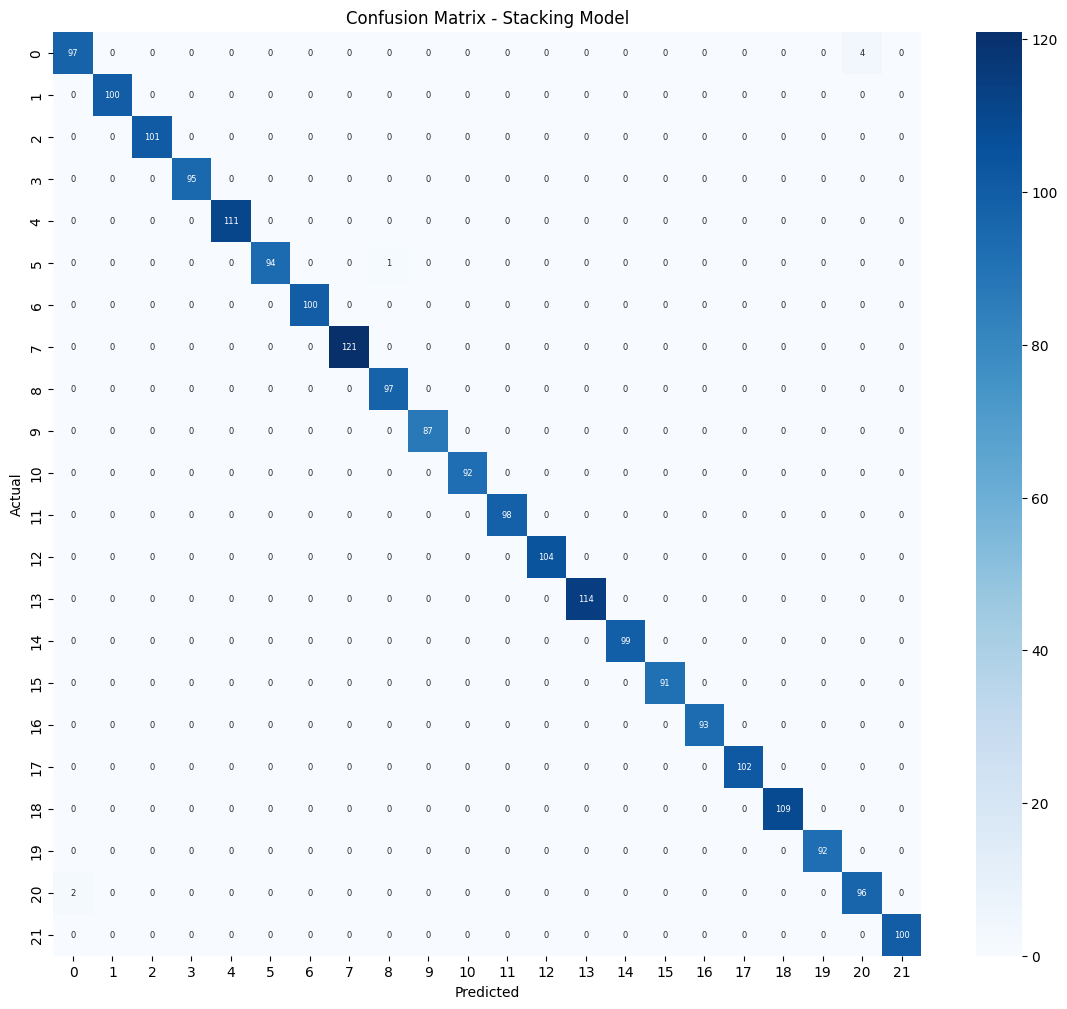

In [177]:
plt.figure(figsize=(14,12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            annot_kws={"size":6})

plt.title("Confusion Matrix - Stacking Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [179]:
from google.colab import files

files.download(f"{save_path}/stack_model.pkl")
files.download(f"{save_path}/scaler.pkl")
files.download(f"{save_path}/mapping.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>